Here, I will explore the percentage of variance in the expression levels of each gene,\
that is explained by each variable in the colData (metadata) of the single cell \
experiment object.

In [1]:
getwd()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/GENE_EXPRESSION/MOUSE/STROKE/2024_Garcia-Bonilla_et_al/22_03_25"

In [2]:
here::here()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/GENE_EXPRESSION/MOUSE/STROKE/2024_Garcia-Bonilla_et_al/22_03_25"

In [3]:
.libPaths()

[1] "/fast/home/y/ykazci/R/x86_64-unknown-linux-gnu-library/4.3"               
[2] "/gnu/store/asn7yfxccx9hqi4afrnw685xw6c6382z-profile/site-library"         
[3] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [4]:
my_gset_lib <- 
    "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/renv_envs/gset/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"

In [5]:
.libPaths(new = my_gset_lib, 
          include.site = FALSE)

In [6]:
.libPaths()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/renv_envs/gset/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"
[2] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [7]:
library(magrittr)

In [8]:
library(Seurat)

Loading required package: SeuratObject

Loading required package: sp

'SeuratObject' was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall 'SeuratObject' as the ABI
for R may have changed


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t




In [9]:
list.files(here::here('r_objects'))

[1] "GBonilla_seurat.RDS"              "GBonilla_seurat_w_Regulons.RDS"  
[3] "pyscenic_regulon_list_object.RDS"

In [10]:
GBonilla_seurat <-  
    readRDS(here::here('r_objects', 'GBonilla_seurat_w_Regulons.RDS'))

In [11]:
GBonilla_seurat

An object of class Seurat 
14539 features across 43269 samples within 2 assays 
Active assay: RNA (14316 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: TF
 3 dimensional reductions calculated: pca, harmony, umap

In [15]:
library(S4Vectors)

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following object is masked from 'package:SeuratObject':

    intersect


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min



Attaching package: 'S4Vectors'


The following object is masked from 'package:utils':

    findMatches


The following objects are masked from 'package:base':

    I, expand.grid, unname




In [16]:
GBonilla_seurat[[]] %>% as('DataFrame')

DataFrame with 43269 rows and 25 columns
                                   orig.ident nCount_RNA nFeature_RNA
                                     <factor>  <numeric>    <integer>
BRS02R1GGGATCGATATG Garcia-Bonilla_et_al_2023       2840          906
BRS02R1ATTCAATATCAC Garcia-Bonilla_et_al_2023       3759         1069
BRS02R1ATTTCCGTCCGC Garcia-Bonilla_et_al_2023       3246         1656
BRS02R1TAGCGCGAGACC Garcia-Bonilla_et_al_2023       3766         1383
BRS02R1GCTGATTATTTG Garcia-Bonilla_et_al_2023       2691         1401
...                                       ...        ...          ...
BRD14R4ACGTCGTCCTGC Garcia-Bonilla_et_al_2023        175          142
BRD14R4TGGGCCATTCGC Garcia-Bonilla_et_al_2023        183          153
BRD14R4GCGTAACCTTAT Garcia-Bonilla_et_al_2023        213          169
BRD14R4GGGCGCGCCAAT Garcia-Bonilla_et_al_2023        172          125
BRD14R4AGTCGTGTTCCG Garcia-Bonilla_et_al_2023        205          164
                    before_filtering_nCount_RNA b

In [23]:
metadata_cells <- GBonilla_seurat %>% slot('meta.data')

In [24]:
continuous_vars <- colnames(metadata_cells)[sapply(metadata_cells, function(x) is.numeric(x) & length(unique(x)) > 10)]

categorical_vars <- colnames(metadata_cells)[sapply(metadata_cells, function(x) is.character(x) | is.factor(x) | length(unique(x)) <= 10)]

In [26]:
continuous_vars %>% print()

[1] "nCount_RNA"                    "nFeature_RNA"                 
[3] "before_filtering_nCount_RNA"   "before_filtering_nFeature_RNA"
[5] "authors_nCount_RNA"            "authors_nFeature_RNA"         
[7] "authors_percent.mt"            "before_filtering_percent.mt"  


In [28]:
categorical_vars %>% print()

 [1] "orig.ident"                "study.ident"              
 [3] "tissue"                    "organism"                 
 [5] "strain"                    "sex"                      
 [7] "age"                       "treatment"                
 [9] "Replicate"                 "Sample_description"       
[11] "sub.celltype"              "parent"                   
[13] "sample"                    "cell_barcodes"            
[15] "main_cell_types"           "before_filtering_res_0_01"
[17] "treatment_and_cell_types" 


In [29]:
categorical_vars <- categorical_vars %>% setdiff("cell_barcodes")

In [30]:
lapply(categorical_vars, function(x) table(GBonilla_seurat %>% slot('meta.data') %>% extract(x)))

[[1]]
orig.ident
Garcia-Bonilla_et_al_2023 
                    43269 

[[2]]
study.ident
GR180125 GR180426 GR180613 GR180614 GR180716 GR180905 GR180919 GR181024 
    2983     3540     2648     3335     3465     2665     3457     4491 
GR181114 GR181128 GR181212 GR190110 
    5121     4714     3048     3802 

[[3]]
tissue
brain 
43269 

[[4]]
organism
mus musculus 
       43269 

[[5]]
strain
C57BL/6J 
   43269 

[[6]]
sex
 male 
43269 

[[7]]
age
  W10    W8 
 6031 37238 

[[8]]
treatment
  D02   D14  Sham 
14823 13417 15029 

[[9]]
Replicate
rep_1 rep_2 rep_3 rep_4 
 9988 10697  9170 13414 

[[10]]
Sample_description
14d stroke; ipsilateral hemisphere; CD45hi + MG + EC 
                                               13417 
               2d sham; hemisphere; CD45hi + MG + EC 
                                               15029 
 2d stroke; ipsilateral hemisphere; CD45hi + MG + EC 
                                               14823 

[[11]]
sub.celltype
 BAM1  BAM2  BAM3  BAM4  BAM

In [31]:
vars_selected <- c(categorical_vars, continuous_vars)

In [32]:
GBonilla_sce <- GBonilla_seurat %>% as.SingleCellExperiment()

In [33]:
GBonilla_sce

class: SingleCellExperiment 
dim: 14316 43269 
metadata(0):
assays(3): counts logcounts scaledata
rownames(14316): 0610009B22Rik 0610009E02Rik ... Tpsab1 Zfp300
rowData names(0):
colnames(43269): BRS02R1GGGATCGATATG BRS02R1ATTCAATATCAC ...
  BRD14R4GGGCGCGCCAAT BRD14R4AGTCGTGTTCCG
colData names(26): orig.ident nCount_RNA ... treatment_and_cell_types
  ident
reducedDimNames(3): PCA HARMONY UMAP
mainExpName: RNA
altExpNames(1): TF

    From scater vignette: 
    "Variable-level metrics are computed by the getVarianceExplained() function 
    (after normalization, see below). This calculates the percentage of variance 
    of each gene’s expression that is explained by each variable in the colData 
    of the SingleCellExperiment object. We can then use this to determine which 
    experimental factors are contributing most to the variance in expression. 
    This is useful for diagnosing batch effects or to quickly verify that 
    a treatment has an effect."

In [39]:
vars_mat <- scater::getVarianceExplained(GBonilla_sce,
    variables= vars_selected)

Warning message in beachmat_internal_FUN(X[[3]], ...):
"ignoring 'orig.ident' with fewer than 2 unique levels"
Warning message in beachmat_internal_FUN(X[[3]], ...):
"ignoring 'tissue' with fewer than 2 unique levels"
Warning message in beachmat_internal_FUN(X[[3]], ...):
"ignoring 'organism' with fewer than 2 unique levels"
Warning message in beachmat_internal_FUN(X[[3]], ...):
"ignoring 'strain' with fewer than 2 unique levels"
Warning message in beachmat_internal_FUN(X[[3]], ...):
"ignoring 'sex' with fewer than 2 unique levels"


In [40]:
vars_mat %>% head()

,orig.ident,study.ident,tissue,organism,strain,sex,age,treatment,Replicate,Sample_description,...,before_filtering_res_0_01,treatment_and_cell_types,nCount_RNA,nFeature_RNA,before_filtering_nCount_RNA,before_filtering_nFeature_RNA,authors_nCount_RNA,authors_nFeature_RNA,authors_percent.mt,before_filtering_percent.mt
0610009B22Rik,NA,0.43512889,NA,NA,NA,NA,0.0670997262,0.070634025,0.02448678,0.070634025,...,0.08952001,0.5744591,0.82703210,1.01682310,0.79896658,0.95623079,0.77637523,0.86023094,0.048471374,0.050635067
0610009E02Rik,NA,0.05287721,NA,NA,NA,NA,0.0076269142,0.003007812,0.01952126,0.003007812,...,0.25503821,0.5248697,0.01638099,0.03825835,0.01598281,0.03547377,0.01646708,0.02708519,0.004898013,0.006022882
0610009L18Rik,NA,0.08774268,NA,NA,NA,NA,0.0284546908,0.003411138,0.04209682,0.003411138,...,0.07583961,0.2657907,0.03425364,0.04574068,0.03524132,0.04485306,0.03585939,0.04128108,0.005492028,0.006171838
0610010F05Rik,NA,0.28131853,NA,NA,NA,NA,0.0031455526,0.134264534,0.03581569,0.134264534,...,0.14559881,0.3804969,0.54936490,0.66811004,0.54591654,0.63579583,0.52795284,0.59001285,0.014710337,0.012668628
0610010K14Rik,NA,0.14493302,NA,NA,NA,NA,0.0001828111,0.020162354,0.06750748,0.020162354,...,0.12757359,0.1445247,0.08774234,0.15053312,0.08586961,0.14232816,0.08537332,0.12362546,0.004816160,0.004869179
0610012G03Rik,NA,1.39674043,NA,NA,NA,NA,0.0417024546,0.907183368,0.14323063,0.907183368,...,0.28958829,1.3262392,2.77491117,3.04189840,2.78248134,2.99377009,2.73083342,2.82950987,0.025165933,0.028101252


In [47]:
vars_df <- vars_mat %>% as.data.frame()

In [48]:
vars_df %>% anyNA()

[1] TRUE

In [50]:
vars_df %>% head()

,orig.ident,study.ident,tissue,organism,strain,sex,age,treatment,Replicate,Sample_description,...,before_filtering_res_0_01,treatment_and_cell_types,nCount_RNA,nFeature_RNA,before_filtering_nCount_RNA,before_filtering_nFeature_RNA,authors_nCount_RNA,authors_nFeature_RNA,authors_percent.mt,before_filtering_percent.mt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610009B22Rik,NA,0.43512889,NA,NA,NA,NA,0.0670997262,0.070634025,0.02448678,0.070634025,...,0.08952001,0.5744591,0.82703210,1.01682310,0.79896658,0.95623079,0.77637523,0.86023094,0.048471374,0.050635067
0610009E02Rik,NA,0.05287721,NA,NA,NA,NA,0.0076269142,0.003007812,0.01952126,0.003007812,...,0.25503821,0.5248697,0.01638099,0.03825835,0.01598281,0.03547377,0.01646708,0.02708519,0.004898013,0.006022882
0610009L18Rik,NA,0.08774268,NA,NA,NA,NA,0.0284546908,0.003411138,0.04209682,0.003411138,...,0.07583961,0.2657907,0.03425364,0.04574068,0.03524132,0.04485306,0.03585939,0.04128108,0.005492028,0.006171838
0610010F05Rik,NA,0.28131853,NA,NA,NA,NA,0.0031455526,0.134264534,0.03581569,0.134264534,...,0.14559881,0.3804969,0.54936490,0.66811004,0.54591654,0.63579583,0.52795284,0.59001285,0.014710337,0.012668628
0610010K14Rik,NA,0.14493302,NA,NA,NA,NA,0.0001828111,0.020162354,0.06750748,0.020162354,...,0.12757359,0.1445247,0.08774234,0.15053312,0.08586961,0.14232816,0.08537332,0.12362546,0.004816160,0.004869179
0610012G03Rik,NA,1.39674043,NA,NA,NA,NA,0.0417024546,0.907183368,0.14323063,0.907183368,...,0.28958829,1.3262392,2.77491117,3.04189840,2.78248134,2.99377009,2.73083342,2.82950987,0.025165933,0.028101252


In [59]:
# Remove all rows NA columns:

In [60]:
vars_df %>% dplyr::select(dplyr::where(function(x) !all(is.na(x)))) %>% head()

,study.ident,age,treatment,Replicate,Sample_description,sub.celltype,parent,sample,main_cell_types,before_filtering_res_0_01,treatment_and_cell_types,nCount_RNA,nFeature_RNA,before_filtering_nCount_RNA,before_filtering_nFeature_RNA,authors_nCount_RNA,authors_nFeature_RNA,authors_percent.mt,before_filtering_percent.mt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610009B22Rik,0.43512889,0.0670997262,0.070634025,0.02448678,0.070634025,0.7722123,0.1985342,0.43512889,0.1985342,0.08952001,0.5744591,0.82703210,1.01682310,0.79896658,0.95623079,0.77637523,0.86023094,0.048471374,0.050635067
0610009E02Rik,0.05287721,0.0076269142,0.003007812,0.01952126,0.003007812,0.5028617,0.3892576,0.05287721,0.3892576,0.25503821,0.5248697,0.01638099,0.03825835,0.01598281,0.03547377,0.01646708,0.02708519,0.004898013,0.006022882
0610009L18Rik,0.08774268,0.0284546908,0.003411138,0.04209682,0.003411138,0.1977129,0.1216640,0.08774268,0.1216640,0.07583961,0.2657907,0.03425364,0.04574068,0.03524132,0.04485306,0.03585939,0.04128108,0.005492028,0.006171838
0610010F05Rik,0.28131853,0.0031455526,0.134264534,0.03581569,0.134264534,0.5060845,0.2173119,0.28131853,0.2173119,0.14559881,0.3804969,0.54936490,0.66811004,0.54591654,0.63579583,0.52795284,0.59001285,0.014710337,0.012668628
0610010K14Rik,0.14493302,0.0001828111,0.020162354,0.06750748,0.020162354,0.2777389,0.1183438,0.14493302,0.1183438,0.12757359,0.1445247,0.08774234,0.15053312,0.08586961,0.14232816,0.08537332,0.12362546,0.004816160,0.004869179
0610012G03Rik,1.39674043,0.0417024546,0.907183368,0.14323063,0.907183368,1.6527846,0.7185267,1.39674043,0.7185267,0.28958829,1.3262392,2.77491117,3.04189840,2.78248134,2.99377009,2.73083342,2.82950987,0.025165933,0.028101252


In [61]:
var_mat_filtered <- vars_df %>% dplyr::select(dplyr::where(function(x) !all(is.na(x)))) %>% as.matrix()

In [62]:
var_mat_filtered %>% head()

,study.ident,age,treatment,Replicate,Sample_description,sub.celltype,parent,sample,main_cell_types,before_filtering_res_0_01,treatment_and_cell_types,nCount_RNA,nFeature_RNA,before_filtering_nCount_RNA,before_filtering_nFeature_RNA,authors_nCount_RNA,authors_nFeature_RNA,authors_percent.mt,before_filtering_percent.mt
0610009B22Rik,0.43512889,0.0670997262,0.070634025,0.02448678,0.070634025,0.7722123,0.1985342,0.43512889,0.1985342,0.08952001,0.5744591,0.82703210,1.01682310,0.79896658,0.95623079,0.77637523,0.86023094,0.048471374,0.050635067
0610009E02Rik,0.05287721,0.0076269142,0.003007812,0.01952126,0.003007812,0.5028617,0.3892576,0.05287721,0.3892576,0.25503821,0.5248697,0.01638099,0.03825835,0.01598281,0.03547377,0.01646708,0.02708519,0.004898013,0.006022882
0610009L18Rik,0.08774268,0.0284546908,0.003411138,0.04209682,0.003411138,0.1977129,0.1216640,0.08774268,0.1216640,0.07583961,0.2657907,0.03425364,0.04574068,0.03524132,0.04485306,0.03585939,0.04128108,0.005492028,0.006171838
0610010F05Rik,0.28131853,0.0031455526,0.134264534,0.03581569,0.134264534,0.5060845,0.2173119,0.28131853,0.2173119,0.14559881,0.3804969,0.54936490,0.66811004,0.54591654,0.63579583,0.52795284,0.59001285,0.014710337,0.012668628
0610010K14Rik,0.14493302,0.0001828111,0.020162354,0.06750748,0.020162354,0.2777389,0.1183438,0.14493302,0.1183438,0.12757359,0.1445247,0.08774234,0.15053312,0.08586961,0.14232816,0.08537332,0.12362546,0.004816160,0.004869179
0610012G03Rik,1.39674043,0.0417024546,0.907183368,0.14323063,0.907183368,1.6527846,0.7185267,1.39674043,0.7185267,0.28958829,1.3262392,2.77491117,3.04189840,2.78248134,2.99377009,2.73083342,2.82950987,0.025165933,0.028101252


In [63]:
var_mat_filtered %>% anyNA()

[1] TRUE

In [64]:
var_mat_filtered  %>% is.na() %>% table() 

.
 FALSE   TRUE 
271966     38 

In [66]:
my_theme <- ggplot2::theme(
    axis.title.x = ggplot2::element_text(size = 14),  # X-axis title size
    axis.title.y = ggplot2::element_text(size = 14),  # Y-axis title size
    axis.text.x  = ggplot2::element_text(size = 14, angle = 45, hjust = 1),  # X-axis tick labels
    axis.text.y  = ggplot2::element_text(size = 14),  # Y-axis tick labels
    legend.text  = ggplot2::element_text(size = 15)   # Legend text size
)

my_margin <- ggplot2::theme(plot.margin = ggplot2::unit(c(1, 1, 1, 1), "cm"))  # Add margin to top, right, bottom, and left margins, respectively.

In [70]:
my_colours = c(
    "#5A5156FF", "#F6222EFF", "#FE00FAFF", "#16FF32FF",
    "#3283FEFF", "#FEAF16FF", "#B00068FF", "#1CFFCEFF", "#90AD1CFF",
    "#2ED9FFFF", "#DEA0FDFF", "#AA0DFEFF", "#F8A19FFF", "#325A9BFF",
    "#C4451CFF", "#1C8356FF", "#85660DFF", "#B10DA1FF", "#FBE426FF",
    "#1CBE4FFF", "#FA0087FF", "#FC1CBFFF", "#F7E1A0FF", "#C075A6FF",
    "#782AB6FF", "#AAF400FF", "#BDCDFFFF", "#822E1CFF", "#B5EFB5FF",
    "#7ED7D1FF", "#1C7F93FF", "#D85FF7FF", "#683B79FF", "#66B0FFFF",
    "#3B00FBFF"
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message in transformation$transform(x):
"NaNs produced"
Warning message in scale_x_log10(breaks = 10^(-3:2), labels = c(0.001, 0.01, 0.1, :
"log-10 transformation introduced infinite values."
Warning message:
"Removed 39 rows containing non-finite outside the scale range
(`stat_density()`)."


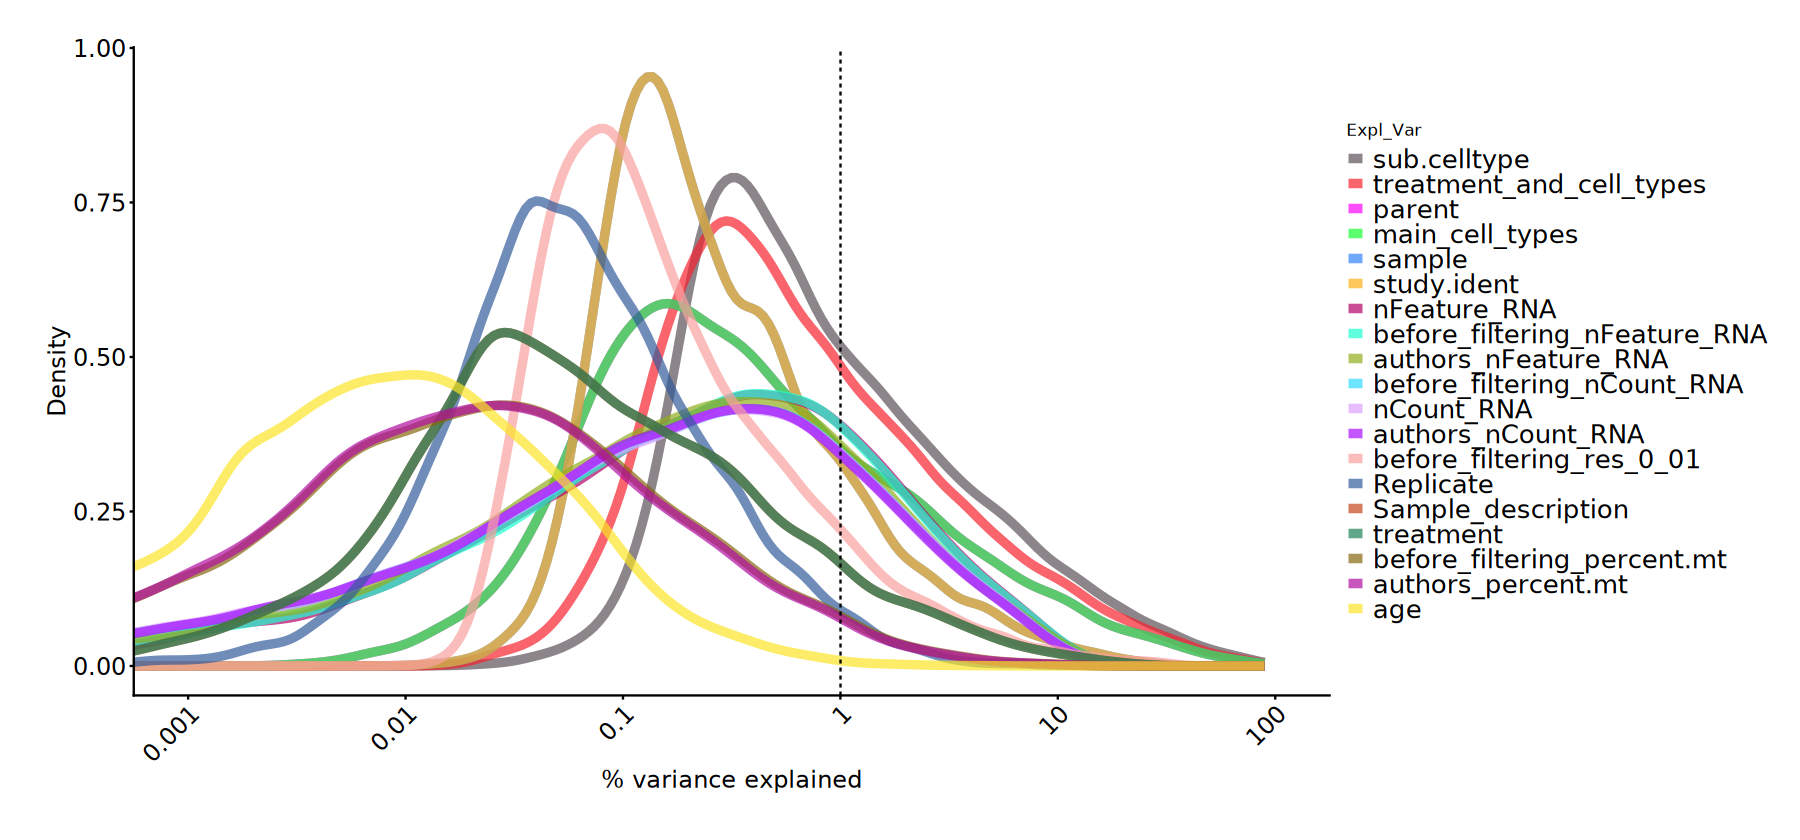

In [74]:
options(repr.plot.width = 15, repr.plot.height = 7) 

scater::plotExplanatoryVariables(var_mat_filtered, nvars_to_plot = Inf, cols = my_colours) + 
ggplot2::scale_color_manual(values = my_colours) + 
my_margin + 
my_theme

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
"Removed 12 rows containing non-finite outside the scale range
(`stat_density()`)."


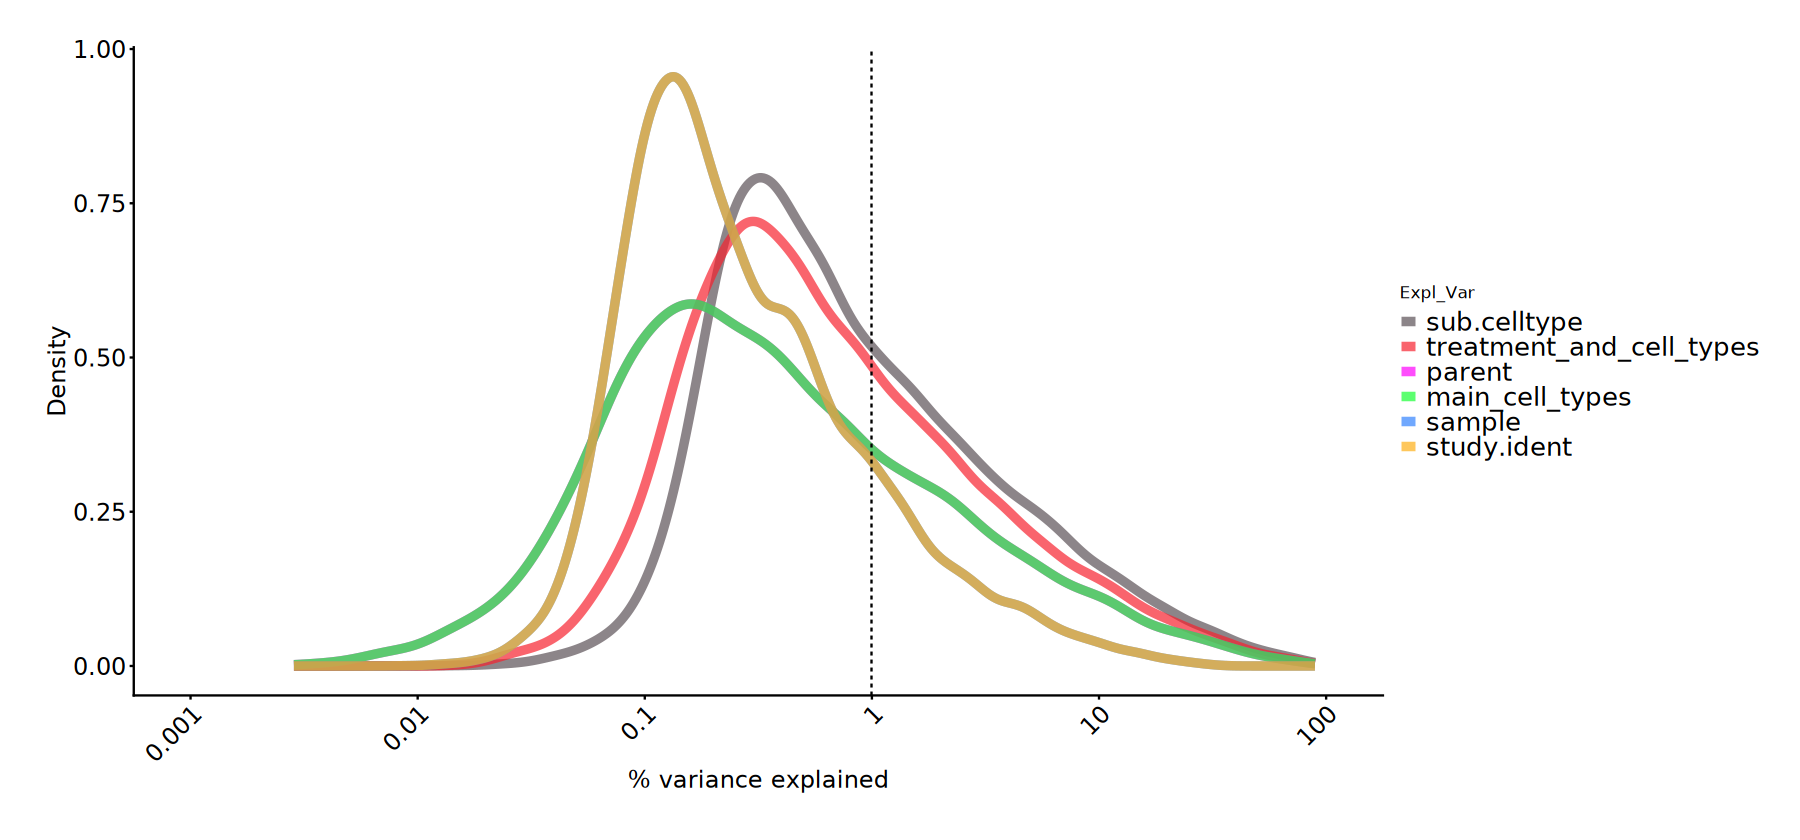

In [81]:
options(repr.plot.width = 15, repr.plot.height = 7) 

scater::plotExplanatoryVariables(var_mat_filtered, nvars_to_plot = 6, cols = my_colours) + 
ggplot2::scale_color_manual(values = my_colours) + 
my_margin + 
my_theme

In [82]:
# Note: parent and main_cell_types are of identical categorical variables.

In [83]:
GBonilla_sce$study.ident %>% table()

.
GR180125 GR180426 GR180613 GR180614 GR180716 GR180905 GR180919 GR181024 
    2983     3540     2648     3335     3465     2665     3457     4491 
GR181114 GR181128 GR181212 GR190110 
    5121     4714     3048     3802 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
"Removed 20 rows containing non-finite outside the scale range
(`stat_density()`)."


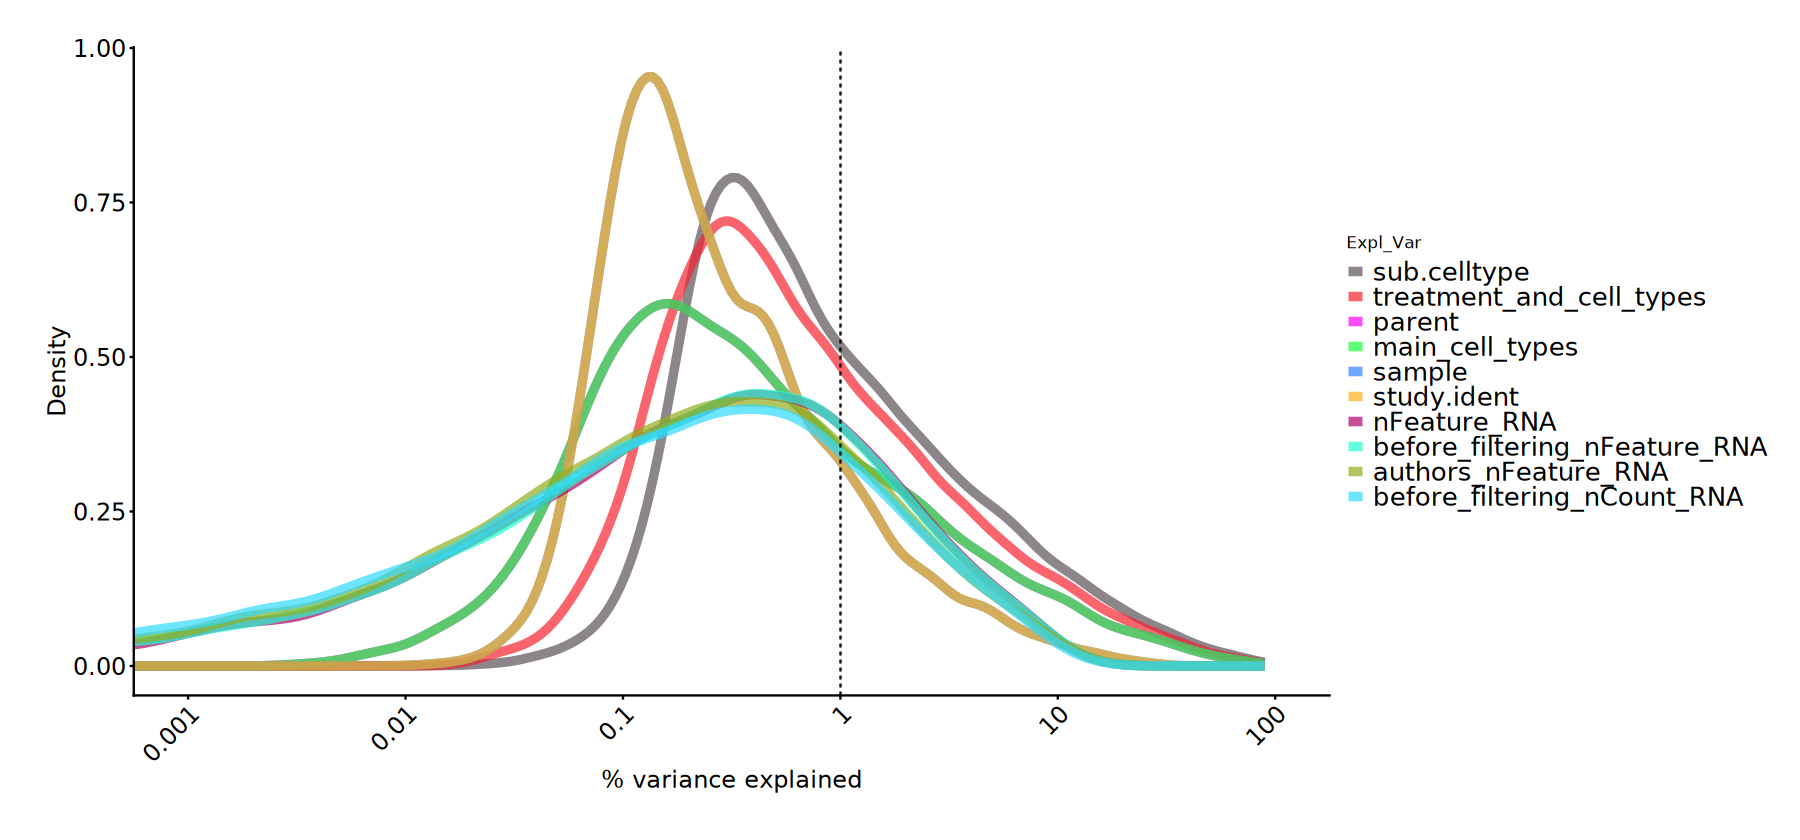

In [84]:
options(repr.plot.width = 15, repr.plot.height = 7) 

scater::plotExplanatoryVariables(var_mat_filtered, nvars_to_plot = 10, cols = my_colours) + 
ggplot2::scale_color_manual(values = my_colours) + 
my_margin + 
my_theme

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
"Removed 30 rows containing non-finite outside the scale range
(`stat_density()`)."


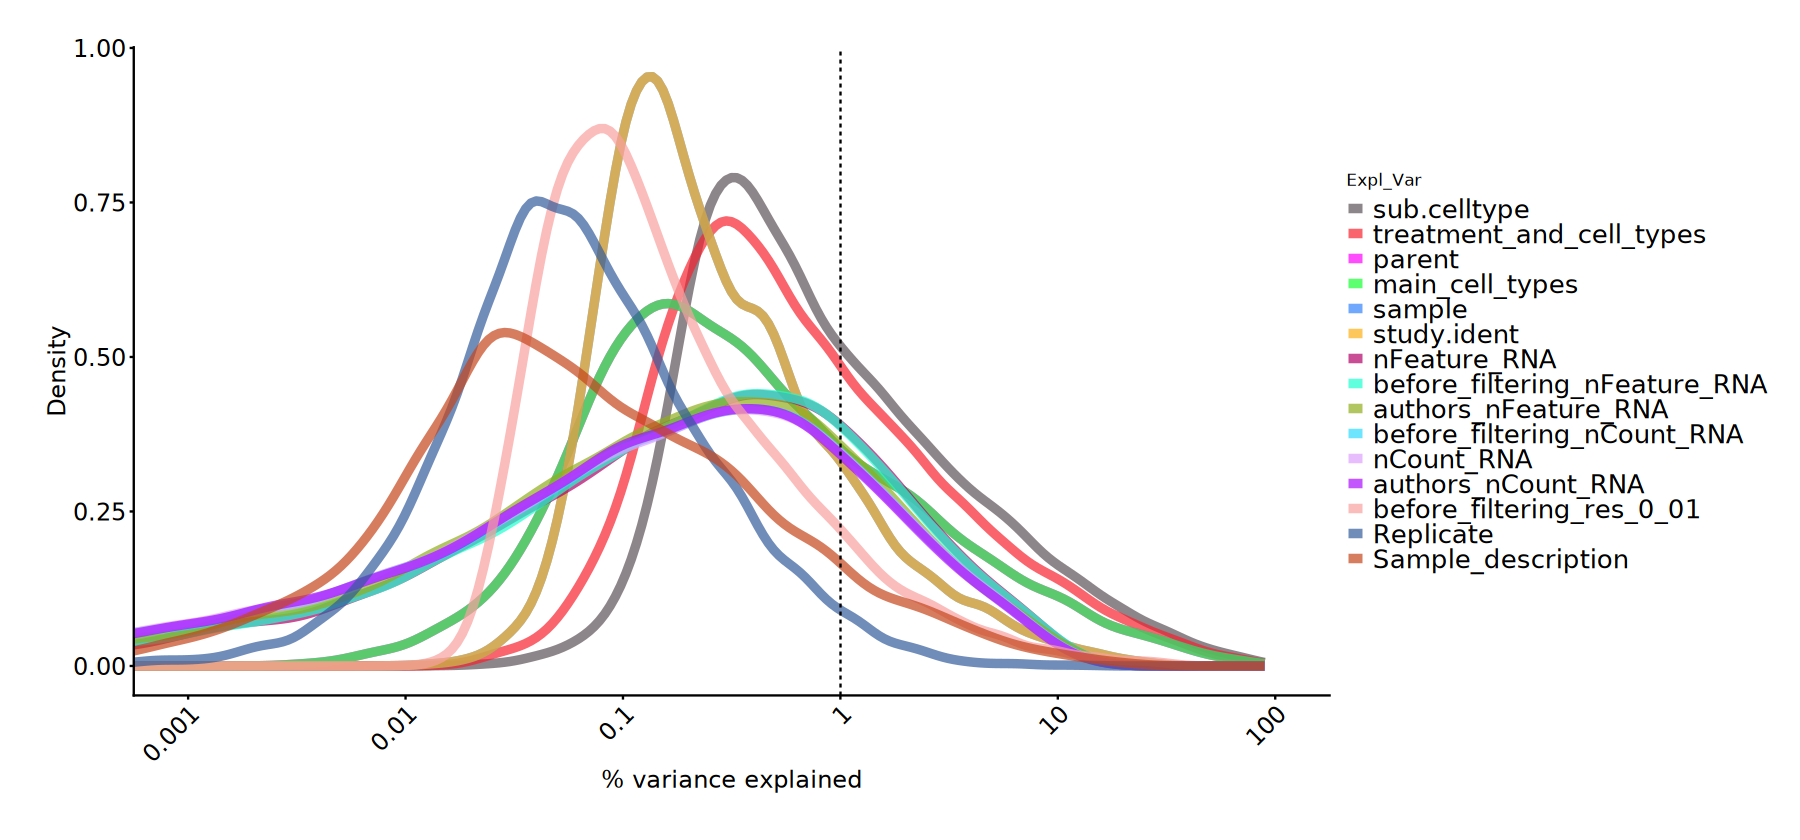

In [85]:
options(repr.plot.width = 15, repr.plot.height = 7) 

scater::plotExplanatoryVariables(var_mat_filtered, nvars_to_plot = 15, cols = my_colours) + 
ggplot2::scale_color_manual(values = my_colours) + 
my_margin + 
my_theme

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
"Removed 2 rows containing non-finite outside the scale range
(`stat_density()`)."


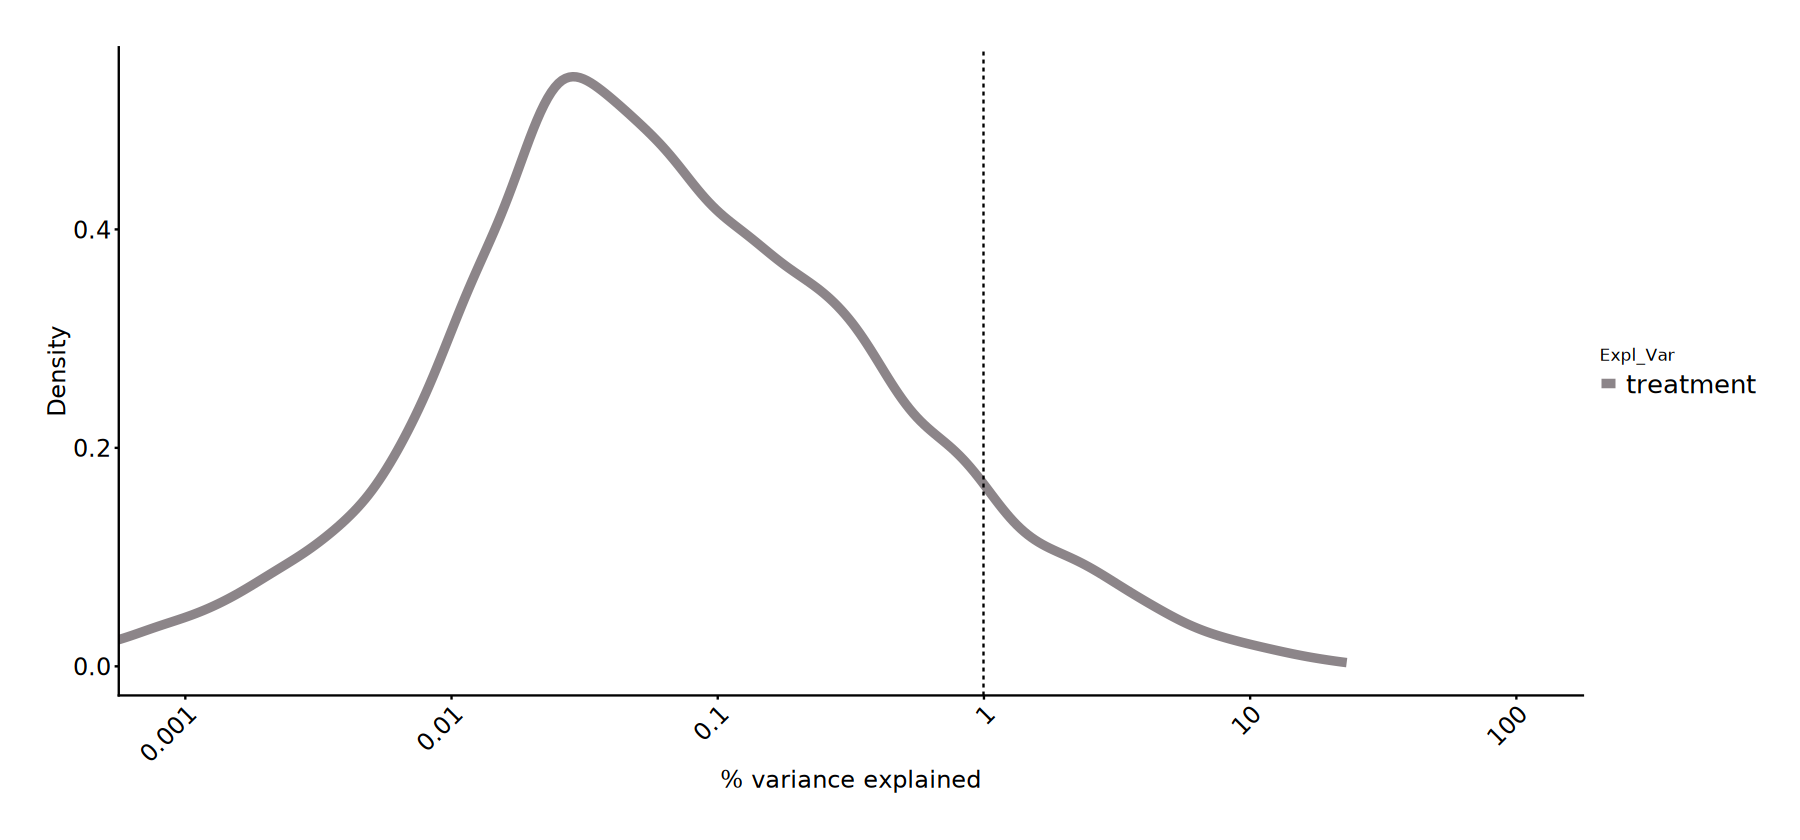

In [93]:
options(repr.plot.width = 15, repr.plot.height = 7) 

scater::plotExplanatoryVariables(var_mat_filtered[, 'treatment', drop = FALSE], nvars_to_plot = 1, cols = my_colours) + 
ggplot2::scale_color_manual(values = my_colours) + 
my_margin + 
my_theme

In [94]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-unknown-linux-gnu
Running under: Red Hat Enterprise Linux 9.4 (Plow)

Matrix products: default
BLAS/LAPACK: /gnu/store/mj1kw87qd3m1q7r4844adkn5hifx8k6a-openblas-0.3.20/lib/libopenblasp-r0.3.20.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=C          LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C.UTF-8
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] S4Vectors_0.42.1    BiocGenerics_0.52.0 Seurat_5.1.0       
[4] SeuratObject_5.0.2  sp_2.1-4            magrittr_2.0.3     

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3          jsonlite_1.8.8             
  [3] ggbeeswarm_0.7.2            spa